# Space–Time Trade-offs in Graph Traversal  
### ***An Empirical Study of BFS, DFS, and Graph Representations***

- Student: **Qiyun Ge**
- Course: 420-A10-AS C2 — Introduction aux structures de donnée
- Instructor: Ali Moridnejad
- April 2026



## **1. Objective**

The goal of this project is to investigate the time–space trade-offs in graph traversal algorithms under different system and representation settings.

Specifically, we aim to analyze:

- The impact of graph representation:
  - adjacency list vs adjacency matrix
- The behavior of traversal algorithms:
  - Breadth-First Search (BFS)
  - Depth-First Search (DFS)
- The influence of runtime environment:
  - Python vs C++

We measure two key aspects:

- **Time complexity (empirical runtime)**  
- **Space usage (peak frontier size during traversal)**

The objective is not only to compare performance, but also to understand how design choices (representation, algorithm, runtime) affect computational efficiency under varying graph densities.

## **2. Methodology**

### ***2.1 Graph Model***

We use randomly generated graphs of fixed size:

- Number of nodes: n = 1000，5000，10000
- Graph type: Random graph G(n, p)
- Density parameter: p ∈ [ 0.05, 0.2,0.5,0.8 ]

The parameter p controls the edge density:
- Small p → sparse graph
- Large p → dense graph

```python
# edge generate process of random graph
        for u in range(n):
            for v in range(n):
                if u != v and rng.random() < p:
                    edges.append((u, v))

```

---

### ***2.2 Graph Representations***

Two common graph representations are evaluated:

- **Adjacency List**
  - Stores only existing edges
  - Efficient for sparse graphs

- **Adjacency Matrix**
  - Stores all possible edges
  - Requires O(n²) space

---

### ***2.3 Traversal Algorithms***

We compare two fundamental traversal strategies:

- **Breadth-First Search (BFS)**
  - Explores nodes level by level
  - Typically uses a queue

- **Depth-First Search (DFS)**
  - Explores along a path before backtracking
  - Typically uses a stack (or recursion)

---

### ***2.4 Runtime Environments***

All experiments are executed in two environments:

- Python implementation
- C++ implementation

This allows us to compare not only algorithmic behavior, but also the impact of language-level performance differences.

---

### ***2.5 Measured Metrics***

For each configuration, we record:

- **Runtime (seconds)**  
  Total execution time of the traversal

- **Peak Frontier Size**  
  Maximum number of nodes held in the frontier (queue/stack) during traversal

- **Visited Nodes Count**  
  Used for sanity checking (should be equal to n for connected graphs)

---

### ***2.6 Theoretical Expectations***

This section summarizes the expected behavior of graph traversal algorithms based on theory.

---

#### 1. BFS vs DFS Runtime

Both BFS and DFS have time complexity:

O(V + E)

- each node is visited once  
- each edge is processed a constant number of times  

**Expectation:**  
BFS and DFS should have **similar runtime performance**

---

#### 2. Graph Representation

- **Adjacency List**
  - O(V + E), iterate only neighbors  

- **Adjacency Matrix**
  - O(V²), scan full row  

**Expectation:**

- List is faster in sparse graphs  
- Gap decreases in dense graphs  

---

#### 3. BFS Space Behavior

- DFS: stack size ≈ depth → small  
- BFS: queue stores frontier → large  

In G(n, p):

- degree ≈ p·n  
- higher density → faster expansion  

**Expectation:**

- BFS frontier increases with density  
- may approach O(n)  
- DFS remains stable  

---

#### 4. Python vs C++

- Python: higher overhead  
- C++: compiled, efficient memory  

**Expectation:**

- C++ is consistently faster  
- difference larger for adjacency list  

---

#### Summary

| Factor | Expected Outcome |
|------|----------------|
| BFS vs DFS | Similar runtime |
| BFS vs DFS (space) | BFS >> DFS |
| List vs Matrix | List faster |
| Density ↑ | BFS frontier ↑ |
| Python vs C++ | C++ faster |

### ***2.7 Experimental Workflow***

Each experiment follows the pipeline:

1. Generate a graph with given parameters (n, p)
2. Construct the chosen graph representation
3. Run the traversal algorithm (BFS or DFS)
4. Measure runtime and peak frontier
5. Record results into a CSV file

The collected dataset is then analyzed in this notebook.

## **3. Experimental Analysis**

This section compares experimental results with the theoretical expectations.

In [11]:

# --- imports ---
from pathlib import Path
import pandas as pd 
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

# --- graph_tradeoff imports ---
from graph_tradeoff.main import main
import graph_tradeoff.config as config
from graph_tradeoff.metrics.metrics import load_results
from graph_tradeoff.metrics.plotting import plotting_config


experiment_name = "experiment_1"
benchmark_path = config.RESULTS_DIR / f"{experiment_name}/benchmark.csv"
if benchmark_path.exists():
    df = load_results(benchmark_path)
else:
    main(experiment_name=experiment_name)
    df = load_results(benchmark_path)


# df.head(20)



In [12]:

# df.count().rename("Count").to_frame().transpose()

## ***3.1 BFS vs DFS Runtime***


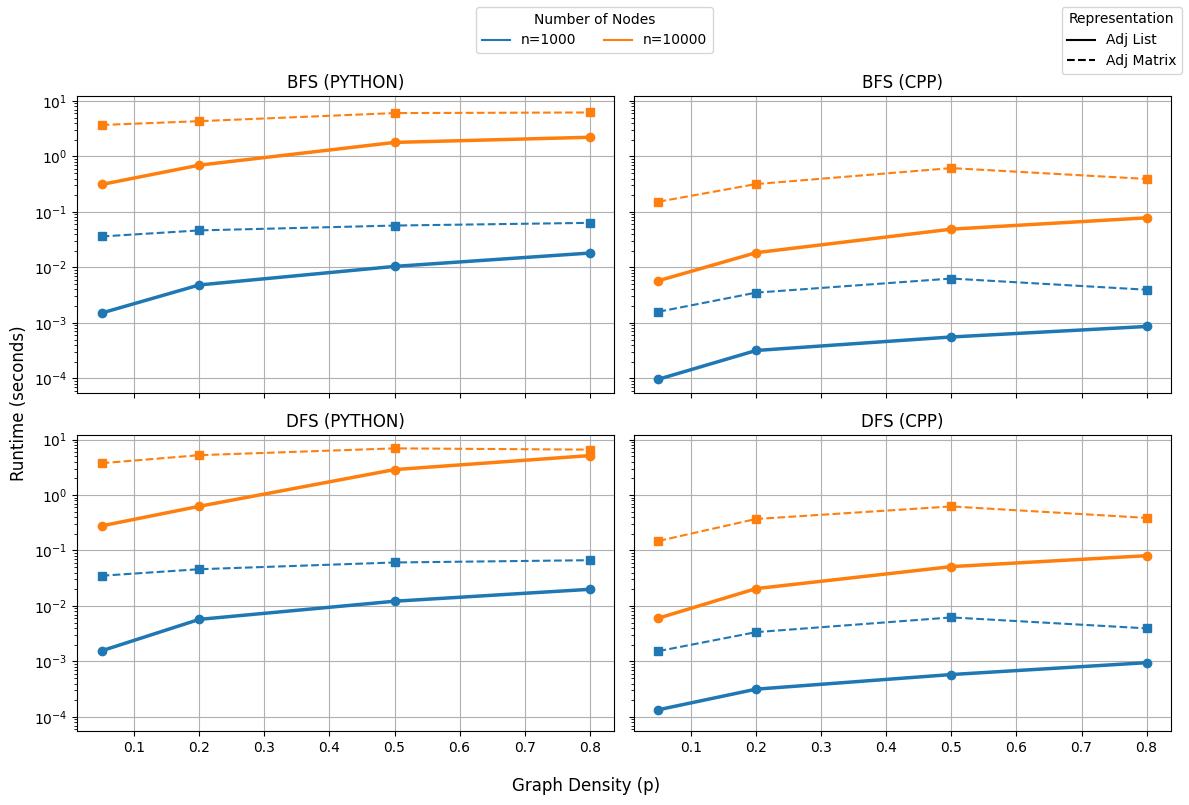

In [13]:

df_plot = df.copy()
df_plot = df_plot.sort_values(by=["traversal_type", "runtime_env", "n", "density_p"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

row_map = {"bfs": 0, "dfs": 1}
col_map = {"python": 0, "cpp": 1}

for (traversal, env), group in df_plot.groupby(["traversal_type", "runtime_env"]):
    r = row_map[traversal]
    c = col_map[env]
    ax = axes[r][c]

    for num, num_group in group.groupby("n"):
        if num == 5000:
            continue

        label_text = False
        for rep, sub in num_group.groupby("graph_representation"):
            sub = sub.sort_values("density_p")

            ax.plot(
                sub["density_p"],
                sub["runtime_sec"],
                linestyle=plotting_config["linestyle_map"].get(rep, "-"),
                linewidth=plotting_config["linewidth_map"].get(rep, 2),
                marker= plotting_config["marker_map"].get(rep, "o"),
                color=plotting_config["color_map"].get(num, None),

                label=f"{rep}"  
            )
            
            

    ax.set_title(f"{traversal.upper()} ({env.upper()})")
    ax.set_yscale("log")
    ax.grid(True)

fig.supxlabel("Graph Density (p)")
fig.supylabel("Runtime (seconds)")

fig.legend(handles=plotting_config["legend_n"], loc="upper center", ncol=3, title="Number of Nodes")
fig.legend(handles=plotting_config["legend_rep"], loc="upper right", title="Representation")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()




**Observation:**

- BFS and DFS show very similar runtime across all settings  

**Explanation:**

- Both have complexity O(V + E)  
- traversal order does not significantly affect total cost  

**Conclusion:**

BFS and DFS have **comparable runtime performance**


### ***3.2 Peak Frontier Comparison***

We analyze peak frontier normalized by graph size.

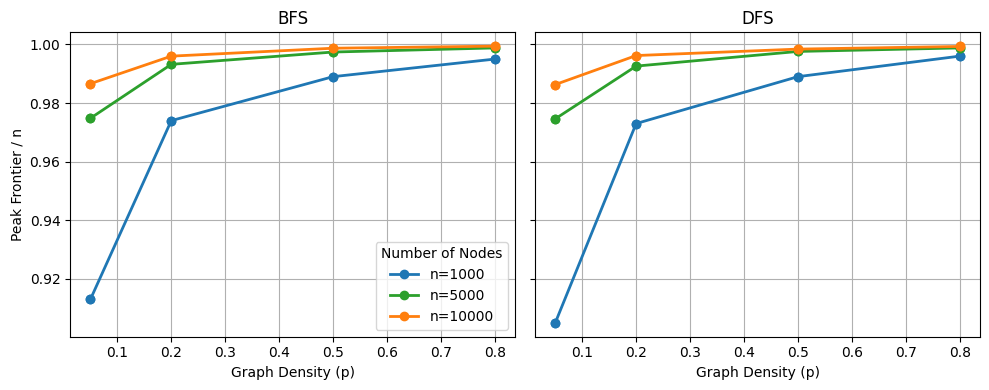

In [14]:
df_space = df[df["graph_representation"] == "adj_list"].copy()
df_space["frontier_ratio"] = df_space["peak_frontier"] / df_space["n"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

traversals = ["bfs", "dfs"]

for i, traversal in enumerate(traversals):
    ax = axes[i]

    group = df_space[df_space["traversal_type"] == traversal]

    for n, sub in group.groupby("n"):
        sub = sub.sort_values("density_p")

        ax.plot(
            sub["density_p"],
            sub["frontier_ratio"],
            marker=plotting_config["marker_map"].get(n, "o"),
            color=plotting_config["color_map"].get(n, None),
            linewidth=2,
            label=f"n={n}"
        )

    ax.set_title(traversal.upper())
    ax.set_xlabel("Graph Density (p)")
    ax.grid(True)

axes[0].set_ylabel("Peak Frontier / n")

axes[0].legend(title="Number of Nodes")

plt.tight_layout()
plt.show()


**Observation:**

- Both BFS and DFS show similar peak frontier ratios  
- The frontier rapidly approaches 1.0 as graph density increases  
- This behavior is consistent across different graph sizes  

**Explanation:**

- In G(n, p), higher density leads to larger expected degree (≈ p·n)  
- The graph becomes highly connected, allowing traversal to quickly reach most nodes  
- As a result, the number of discovered nodes rapidly approaches n  

- The similarity between BFS and DFS indicates that, in dense random graphs, traversal strategy has limited impact on the maximum explored node set  

**Conclusion:**

Peak frontier size is primarily determined by **graph density and connectivity**, rather than traversal algorithm or graph representation

### ***3.3 Runtime Environment Comparison***

We examine the performance gap between the Python and C++ implementations by analyzing the runtime ratio (Python runtime / C++ runtime). This allows us to determine whether the runtime environment changes only the constant factor or also affects the overall scaling trend.

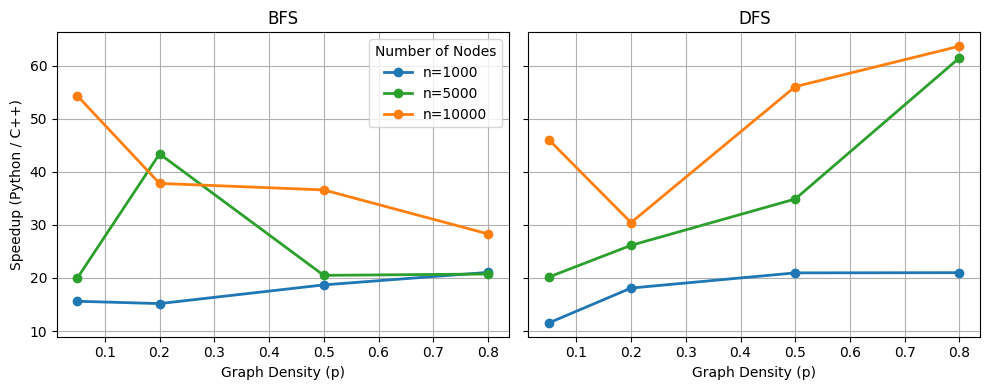

In [15]:
df_time = df[df["graph_representation"] == "adj_list"].copy()

pivot_df = df_time.pivot_table(
    index=["traversal_type", "n", "density_p"],
    columns="runtime_env",
    values="runtime_sec"
).reset_index()


pivot_df["speedup"] = pivot_df["python"] / pivot_df["cpp"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

traversals = ["bfs", "dfs"]

for i, traversal in enumerate(traversals):
    ax = axes[i]

    group = pivot_df[pivot_df["traversal_type"] == traversal]

    for n, sub in group.groupby("n"):
        sub = sub.sort_values("density_p")

        ax.plot(
            sub["density_p"],
            sub["speedup"],
            marker=plotting_config["marker_map"].get(n, "o"),
            color=plotting_config["color_map"].get(n, None),
            linewidth=2,
            label=f"n={n}"
        )

    ax.set_title(traversal.upper())
    ax.set_xlabel("Graph Density (p)")
    ax.grid(True)

axes[0].set_ylabel("Speedup (Python / C++)")

axes[0].legend(title="Number of Nodes")

plt.tight_layout()
plt.show()

**Observation:**

- C++ is consistently faster than Python  

**Explanation:**

- Python: interpreter + dynamic typing  
- C++: compiled + better memory efficiency  

**Conclusion:**

Implementation language introduces **large constant-factor differences**


### ***3.4 Measurement Noise***

**Observation:**

- Small fluctuations appear in runtime results  

**Explanation:**

- execution time is very small  
- affected by system noise (CPU, cache, scheduling)  

**Conclusion:**

Results are valid, but **averaging multiple runs would improve stability**

## **4. Conclusion**

This project analyzed the time–space trade-offs of graph traversal under different representations and runtime environments.

---

### ***Key Findings***

- BFS and DFS have **similar runtime**, confirming their shared complexity O(V + E)  
- Adjacency list **outperforms matrix**, especially in sparse graphs  
- C++ provides **substantial speedup** over Python  

---

### ***Final Insight***

Performance is primarily determined by:

- **data representation** (list vs matrix)  
- **execution environment** (Python vs C++)  

rather than the choice between BFS and DFS.

---

### ****Limitation***

- Runtime measurements are affected by noise due to very small execution time  
- More reliable results require repeated runs and averaging  

---

### ***Takeaway***

> In practical systems, data structures and implementation choices often matter more than asymptotic algorithm differences.